In [1]:
suppressPackageStartupMessages({
  require(data.table)
  require(ggplot2)
  require(dplyr)
  library(ggpubr)
  require(tidyr)
  library(reshape2)
  library(ComplexHeatmap)
})

source('../utilities/functions/helper_functions_olink.R')

In [2]:
plasma <- readRDS('../../data/figure-inputs/olink/MM_Plasma_Olink_Final.rds')

In [3]:
### First split the healthy subjects  
### then extract only Flu Year 1 day 0 samples 
healthy = plasma[plasma$cohort.cohortGuid %in% c('BR1','BR2')]
healthy = healthy[sample.visitDetails =='Flu_Y1D0']

mm_treatment = plasma[sample.visitDetails %in% c('PreTx','PI2C','EI','ASCT60d', 'ASCT1y','ASCT2y')]

healthy$Cohort = 'Healthy'
mm_treatment$Cohort = 'NDMM'

plasma_treatment = rbind(healthy, mm_treatment)
plasma_treatment[sample.visitDetails == 'Flu_Y1D0', sample.visitDetails := 'Healthy']     

In [4]:
plasma_longitudinal_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_pairwise_deps.csv')
plasma_healthy_comparisons <- fread('../../data/figure-inputs/olink/plasma_longitudinal_comparisons_to_healthy.csv')

In [5]:
tp_color_map <- c(
  'PreTx'    = '#8B0000',
  'PI2C'     = '#C20272',
  'EI'       = '#7502C2',
  'ASCT60d'  = '#0021B0',
  'ASCT90d'  = '#2346DE',
  'ASCT1y'   = '#038AFF',
  'ASCT2y'   = '#008080',
  'Healthy'  = '#00470D'
)

In [6]:
create_summary_pval <- function(plasma_healthy_comparisons){
    pval_df <- plasma_healthy_comparisons
    setDT(pval_df)
    setDT(plasma_treatment)
    
    pval_df$olink.assay <- pval_df$Assay
    pval_df$group1 <- pval_df$Time1
    pval_df$group2 <- pval_df$Time2
    
    pval_df <- unique(pval_df, by = c("olink.assay", "group1", "group2"))
    
    pval_df[, label := fifelse(
      adjP < 0.001, "***",
      fifelse(
        adjP < 0.01, "**",
        fifelse(adjP < 0.05, "*", "ns")
      )
    )]
    
    max_positions <- plasma_treatment[,
      list(y.position = max(olink.NPX_norm, na.rm = TRUE) + 0.5), 
      by = olink.assay
    ]
    
    pval_df <- dplyr::left_join(pval_df, max_positions)
}

In [7]:
plot_protein_groups_with_pvals <- function(
    prots = NULL,
    mat = plasma_treatment,
    timePoints = c("PreTx", "PI2C", "EI", "Healthy"),
    healthy_pval_df,
    longitudinal_pval_df,
    tname = "",
    ncol = NULL) {
  plot_df <- mat[olink.assay %in% prots & sample.visitDetails %in% timePoints]
  healthy_pval_df <- healthy_pval_df[olink.assay %in% prots & group1 %in% timePoints & group2 %in% timePoints]
  longitudinal_pval_df <- longitudinal_pval_df[olink.assay %in% prots & group1 %in% timePoints & group2 %in% timePoints]

  ggplot(
    plot_df,
    aes(
      x = sample.visitDetails,
      y = olink.NPX_norm,
      group = subject.subjectGuid,
      fill = sample.visitDetails
    )
  ) +
    geom_violin(aes(group = sample.visitDetails), alpha = 0.5) +
    geom_point(aes(color = sample.visitDetails), alpha = 0.7, size = 1.5) +
    facet_wrap(~olink.assay, ncol = ncol, scales = "free_y") +
    stat_pvalue_manual(
      healthy_pval_df[adjP < 0.05, ],
      xmin = "group1",
      xmax = "group2",
      y.position = "y.position",
      label = "label",
      col = "#006400",
      step.increase = 0.01,
      tip.length = 0.005,
      size = 6,
      bracket.size = 0.8
    ) +
    scale_fill_manual(values = tp_color_map) +
    scale_color_manual(values = tp_color_map) +
    theme_classic(base_size = 20) +
    theme(
      text = element_text(size = 24),
      axis.text.x = element_text(size = 20, angle = 45, hjust = 1),
      axis.text.y = element_text(size = 20),
      axis.title.y = element_text(size = 20),
      strip.text = element_text(size = 20, hjust = 0, face = "bold"),
      strip.background = element_blank(),
      legend.position = "none",
      plot.title = element_text(face = "bold")
    ) +
    labs(x = "", y = "Olink NPX") +
    ggtitle(tname)
}
healthy_pval_df <- create_summary_pval(plasma_healthy_comparisons)
longitudinal_pval_df <- create_summary_pval(plasma_longitudinal_comparisons)
healthy_pval_df$y.position <- healthy_pval_df$y.position + 2

Joining with `by = join_by(olink.assay)`


Joining with `by = join_by(olink.assay)`


In [8]:
options(repr.plot.width = 20, repr.plot.height = 5)
protlist <- c("TGFB1", "TGFBR2", "TNF", "TNFSF10", "TNFSF13B", "HGF", "MET")

p <- plot_protein_groups_with_pvals(
  prots = protlist,
  timePoints = c("PreTx", "Healthy"),
  healthy_pval_df = healthy_pval_df,
  longitudinal_pval_df = longitudinal_pval_df, ncol = 7
) + theme(legend.position = "none")

ggsave("../../data/figure-outputs/supplementary-1/sup_1i.pdf", plot = p, width = 20, height = 5, dpi = 200, device = cairo_pdf)

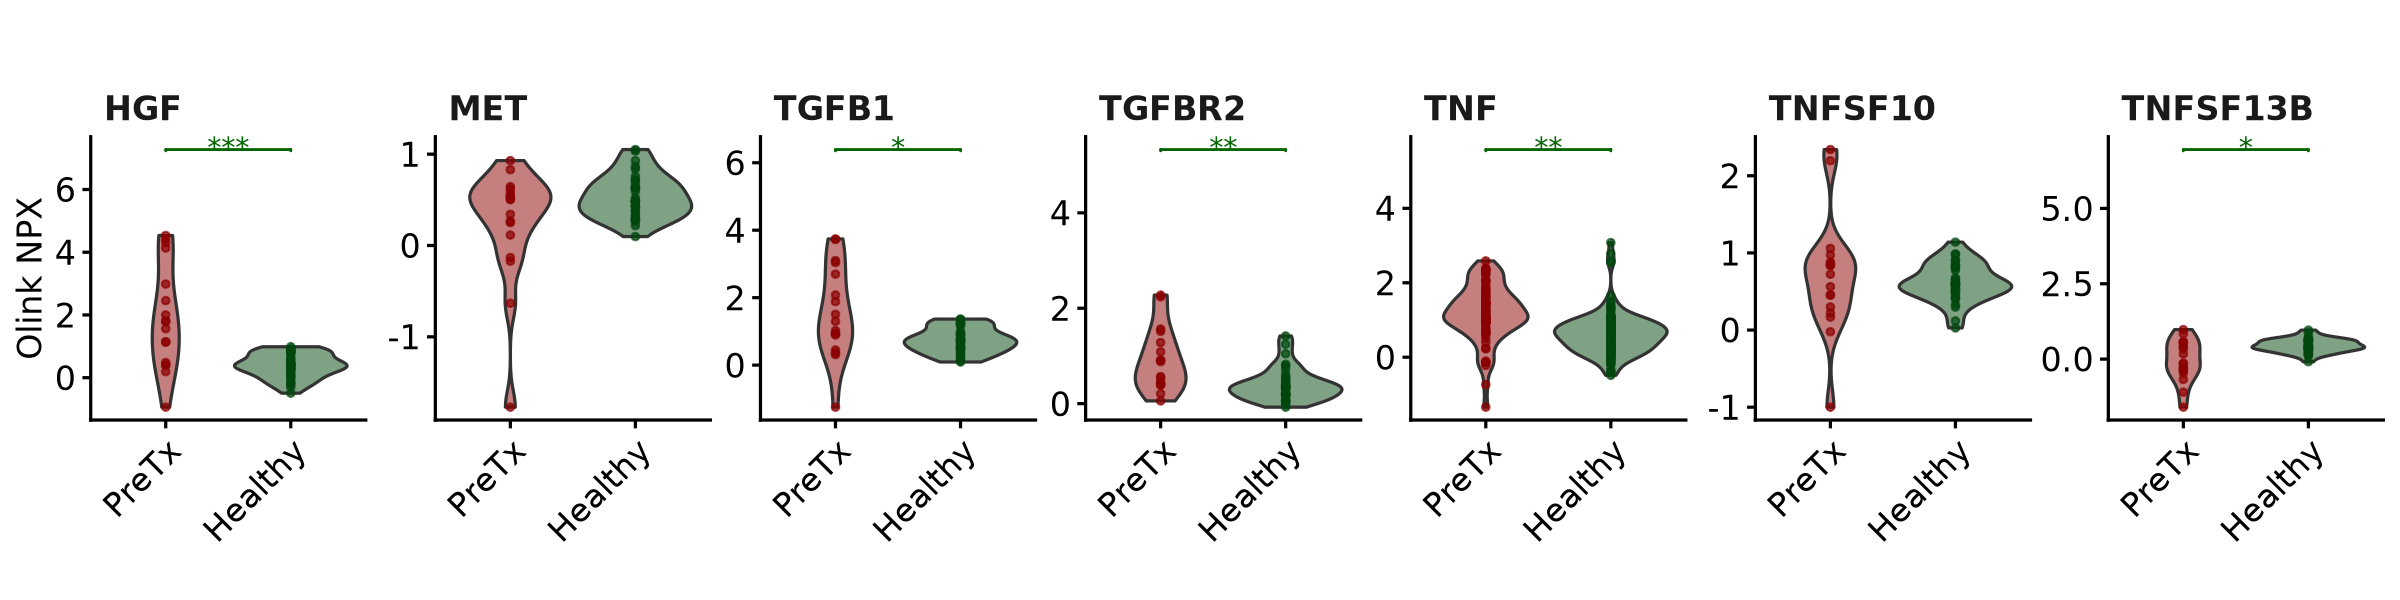

In [9]:
p